In [1]:
!pip install xgboost lightgbm imbalanced-learn shap -q

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

df = df.drop(columns=['Unnamed: 0'], errors='ignore')
X = df.drop(columns=['F3924'])
y = df['F3924']

for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

key_features = ['F115','F321','F527','F531','F670','F1692',
                'F2082','F2122','F2582','F2678','F2737','F2956',
                'F3043','F3836','F3887','F3889','F3891','F3894']
X = X[key_features]

imp = SimpleImputer(strategy='median')
X_imp = imp.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=42, stratify=y
)

sm = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
model.fit(X_train_bal, y_train_bal)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(f"AUC-ROC   : {roc_auc_score(y_test, y_prob):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred)*100:.1f}%")
print(f"Precision : {precision_score(y_test, y_pred, zero_division=0)*100:.1f}%")
print(f"F1 Score  : {f1_score(y_test, y_pred):.3f}")

cm = confusion_matrix(y_test, y_pred)
print(f"\nMules caught : {cm[1][1]} / {y_test.sum()}")
print(f"Mules missed : {cm[1][0]}")
print(f"False alarms : {cm[0][1]}")

print("\nThreshold Tuning:")
for threshold in [0.5, 0.4, 0.3, 0.2, 0.1]:
    y_new = (y_prob > threshold).astype(int)
    cm2 = confusion_matrix(y_test, y_new)
    print(f"  {threshold} → Caught: {cm2[1][1]}/{y_test.sum()} | "
          f"Recall: {recall_score(y_test, y_new)*100:.0f}% | "
          f"False alarms: {cm2[0][1]}")

Saving DataSet.csv to DataSet.csv
AUC-ROC   : 0.939
Recall    : 56.2%
Precision : 8.2%
F1 Score  : 0.143

Mules caught : 9 / 16
Mules missed : 7
False alarms : 101

Threshold Tuning:
  0.5 → Caught: 9/16 | Recall: 56% | False alarms: 101
  0.4 → Caught: 11/16 | Recall: 69% | False alarms: 151
  0.3 → Caught: 13/16 | Recall: 81% | False alarms: 219
  0.2 → Caught: 16/16 | Recall: 100% | False alarms: 306
  0.1 → Caught: 16/16 | Recall: 100% | False alarms: 483


In [3]:
y_pred_final = (y_prob > 0.2).astype(int)

In [2]:
y_pred_final = (y_prob > 0.3).astype(int)

Saving DataSet.csv to DataSet (1).csv
AUC-ROC   : 0.939
Recall    : 56.2%
Precision : 8.2%
F1 Score  : 0.143

Mules caught : 9 / 16
Mules missed : 7
False alarms : 101

Threshold Tuning:
  0.5 → Caught: 9/16 | Recall: 56% | False alarms: 101
  0.4 → Caught: 11/16 | Recall: 69% | False alarms: 151
  0.3 → Caught: 13/16 | Recall: 81% | False alarms: 219
  0.2 → Caught: 16/16 | Recall: 100% | False alarms: 306
  0.1 → Caught: 16/16 | Recall: 100% | False alarms: 483

Final Model (threshold 0.3):
Mules caught : 13 / 16
False alarms : 219
Recall       : 81.2%

5-Fold Cross Validation:
  Fold 1: AUC = 0.800
  Fold 2: AUC = 0.809
  Fold 3: AUC = 0.797
  Fold 4: AUC = 0.878
  Fold 5: AUC = 0.803
  Average AUC: 0.817


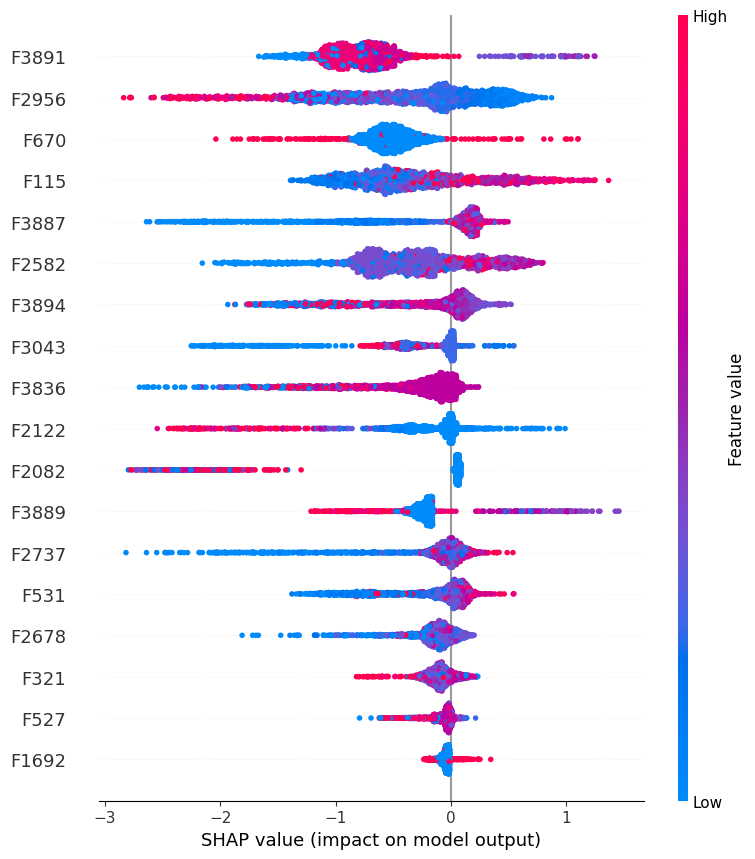

SHAP plot saved!


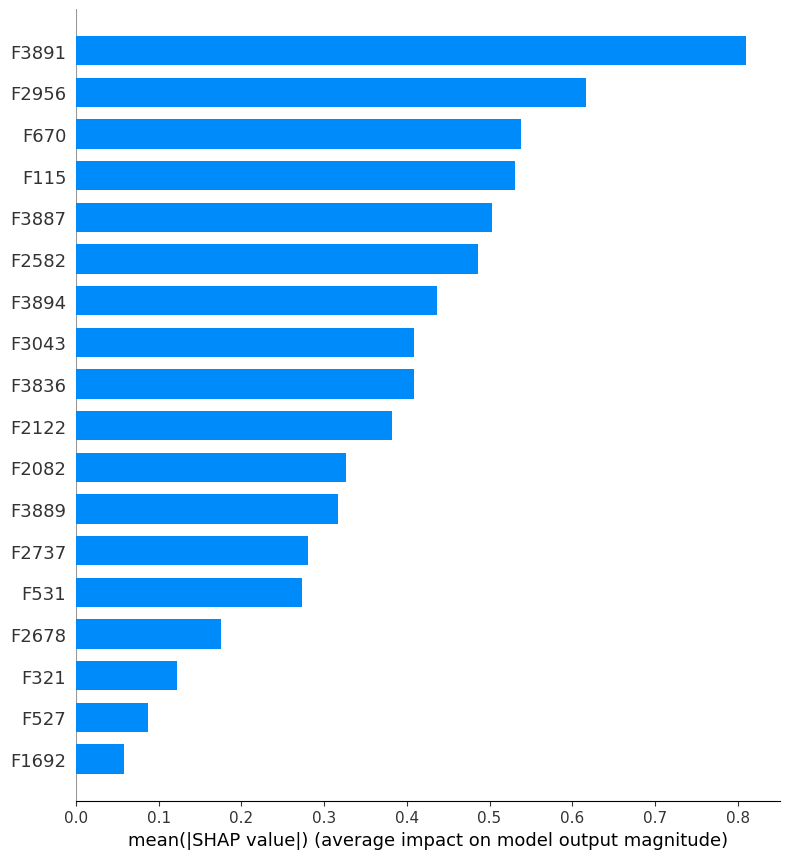

SHAP bar chart saved!


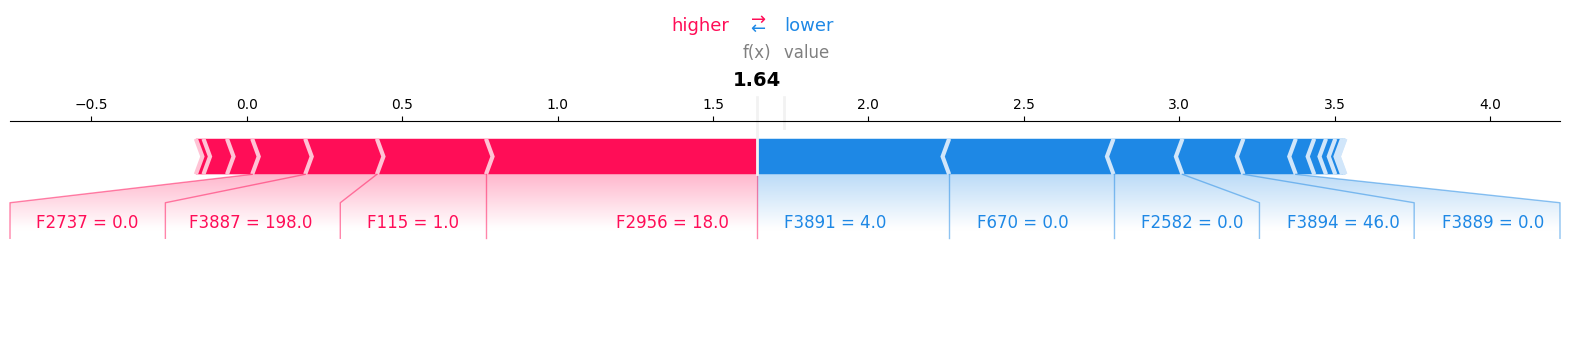

SHAP force plot saved!


In [4]:
!pip install xgboost lightgbm imbalanced-learn shap -q

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

df = df.drop(columns=['Unnamed: 0'], errors='ignore')
X = df.drop(columns=['F3924'])
y = df['F3924']

for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

key_features = ['F115','F321','F527','F531','F670','F1692',
                'F2082','F2122','F2582','F2678','F2737','F2956',
                'F3043','F3836','F3887','F3889','F3891','F3894']
X = X[key_features]

imp = SimpleImputer(strategy='median')
X_imp = imp.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=42, stratify=y
)

sm = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
model.fit(X_train_bal, y_train_bal)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(f"AUC-ROC   : {roc_auc_score(y_test, y_prob):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred)*100:.1f}%")
print(f"Precision : {precision_score(y_test, y_pred, zero_division=0)*100:.1f}%")
print(f"F1 Score  : {f1_score(y_test, y_pred):.3f}")
cm = confusion_matrix(y_test, y_pred)
print(f"\nMules caught : {cm[1][1]} / {y_test.sum()}")
print(f"Mules missed : {cm[1][0]}")
print(f"False alarms : {cm[0][1]}")

print("\nThreshold Tuning:")
for threshold in [0.5, 0.4, 0.3, 0.2, 0.1]:
    y_new = (y_prob > threshold).astype(int)
    cm2 = confusion_matrix(y_test, y_new)
    print(f"  {threshold} → Caught: {cm2[1][1]}/{y_test.sum()} | "
          f"Recall: {recall_score(y_test, y_new)*100:.0f}% | "
          f"False alarms: {cm2[0][1]}")

y_pred_final = (y_prob > 0.3).astype(int)
cm_final = confusion_matrix(y_test, y_pred_final)
print(f"\nFinal Model (threshold 0.3):")
print(f"Mules caught : {cm_final[1][1]} / {y_test.sum()}")
print(f"False alarms : {cm_final[0][1]}")
print(f"Recall       : {recall_score(y_test, y_pred_final)*100:.1f}%")

print("\n5-Fold Cross Validation:")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = []
for fold, (tr_idx, te_idx) in enumerate(skf.split(X_imp, y)):
    X_tr, X_te = X_imp[tr_idx], X_imp[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]
    sm2 = SMOTE(random_state=42, k_neighbors=5)
    X_tr_b, y_tr_b = sm2.fit_resample(X_tr, y_tr)
    m = xgb.XGBClassifier(n_estimators=100, max_depth=4,
                           learning_rate=0.1, verbosity=0,
                           eval_metric='logloss')
    m.fit(X_tr_b, y_tr_b)
    auc = roc_auc_score(y_te, m.predict_proba(X_te)[:,1])
    auc_scores.append(auc)
    print(f"  Fold {fold+1}: AUC = {auc:.3f}")
print(f"  Average AUC: {np.mean(auc_scores):.3f}")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=key_features, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP plot saved!")

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=key_features,
                  plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP bar chart saved!")

mule_indices = np.where(y_test == 1)[0]
if len(mule_indices) > 0:
    shap.force_plot(
        explainer.expected_value,
        shap_values[mule_indices[0]],
        X_test[mule_indices[0]],
        feature_names=key_features,
        matplotlib=True,
        show=False
    )
    plt.savefig('shap_force.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("SHAP force plot saved!")